In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

import aymansigmri as asm



In [2]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

data, n_coils, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)

kspace_posthankel = asm.hankel_H(data_matrix=data, n_coils=12, Nx=kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[1], w=5)

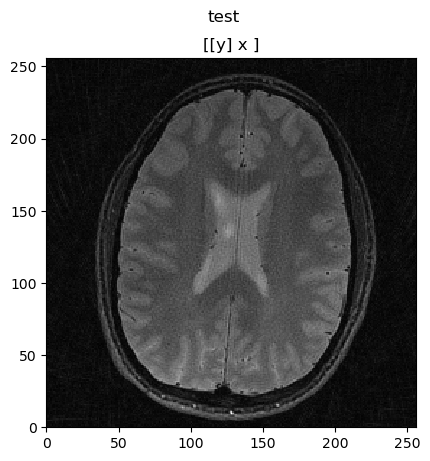

In [3]:
dcf = (zte_radial_coords[...,0]**2 + zte_radial_coords[...,1]**2)**0.5
zte_missing_im_grid = sp.nufft_adjoint(zte_radial_kspace* dcf, zte_radial_coords)

img_rss = np.sum(np.abs(zte_missing_im_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss, title='test')

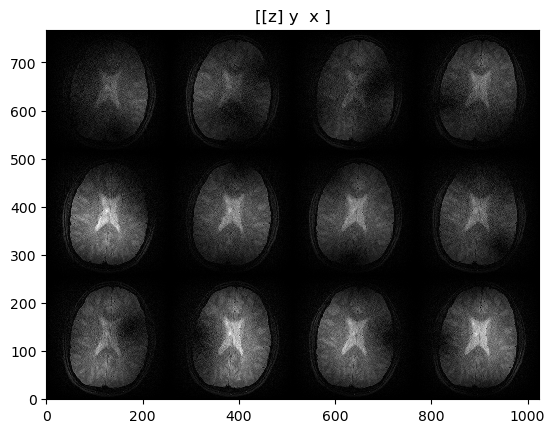

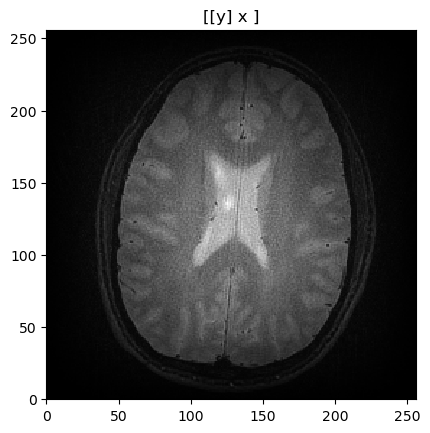

In [4]:
im_grid = sp.ifft(kspace_posthankel)
pl.ImagePlot(im_grid, z=0)
im_rss_posthankel_grid = np.sum(np.abs(im_grid)**2, axis=0)**0.5
pl.ImagePlot(im_rss_posthankel_grid)

In [5]:
U, S, Vh = np.linalg.svd(data, full_matrices=False)

In [6]:
def lower_rank(Sigma, zero_thresh = 0.015):
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    return(np.array(arr))

In [7]:
def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def svd_recon(u, s_reduced, vh):
    return u @ np.diag(s_reduced) @ vh

In [8]:
U, S_reduced, Vh = sig_val_thresholding(data=data, zero_thresh=0.15)
data_recon = svd_recon(u=U, s_reduced=S_reduced, vh=Vh)

In [9]:
S_reduced = lower_rank(Sigma = S,zero_thresh=0.15)
S_matrix = np.zeros((data.shape))
np.fill_diagonal(S_matrix, S_reduced)
data_recon = (U * S_reduced) @ Vh

In [10]:
kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=12, Nx=256, Ny =256, w=5)

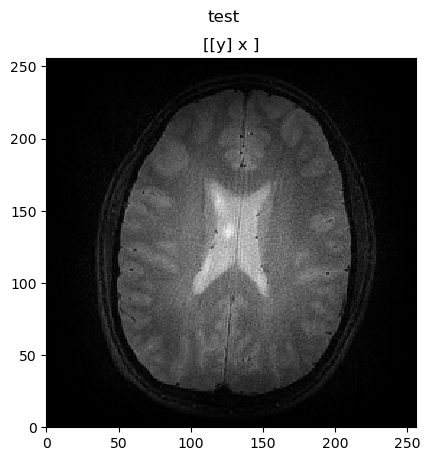

In [11]:
grid_recon = sp.ifft(kspace_cart_coils_recon)
img_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
pl.ImagePlot(img_rss_recon, title='test')